<a href="https://colab.research.google.com/github/Hesam-s/NLP/blob/main/MAD_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reproducing Cross-lingual Named Entity Recognition Using XLM-RoBERTa, Task Adapters, and WikiANN

---

<p align="center">
  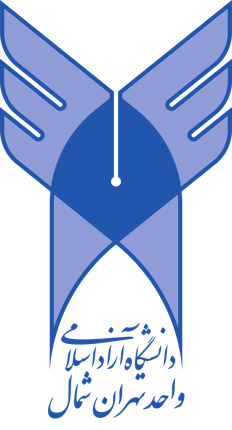
</p><br>

---

# اطلاعات پروژه

**نام درس:** (NLP Advanced) پردازش زبان‌های طبیعی پیشرفته

**استاد درس:** دکتر نوا اسلامی

**دانشگاه:** آزاد اسلامی واحد تهران شمال

**نیمسال تحصیلی:** نیمسال دوم سال تحصیلی 1404-1405

---

# اعضای گروه

| نام و نام خانوادگی | شماره دانشجویی |
|---------------------|----------------|
| حسام ثروتی | 404198788 |
| محمدمهدی نصرتی | 404188074 |

---

# عنوان پروژه

## Reproducing the Task Adapter Component of the MAD-X Framework for Cross-lingual Named Entity Recognition (NER)

### Using XLM-RoBERTa and the WikiANN Dataset

---

# مقاله مرجع

**عنوان مقاله:**

**MAD-X: An Adapter-Based Framework for Multi-task Cross-lingual Transfer**

**نویسندگان:**

- Jonas Pfeiffer
- Ivan Vulić
- Iryna Gurevych
- Sebastian Ruder

**کنفرانس:**

Proceedings of the 2020 Conference on Empirical Methods in Natural Language Processing (EMNLP 2020)

---

# هدف پروژه

The objective of this project is to reproduce the task adapter approach for cross-lingual **Named Entity Recognition (NER)** inspired by the MAD-X framework and evaluate its ability to transfer knowledge from a high-resource language (**English**) to a lower-resource language (**Persian**).

In this project, **XLM-RoBERTa Base** is used as the backbone model. A **Task Adapter** is trained on the English portion of the **WikiANN** dataset and then directly applied to Persian using **zero-shot cross-lingual transfer**. This approach demonstrates the multilingual transfer capability of XLM-RoBERTa without fine-tuning the entire pretrained model or using additional target-language training data.

---

# مشخصات پروژه

| Component | Value |
|-----------|-------|
| Framework | Task Adapter Approach (Inspired by MAD-X) |
| Backbone Model | XLM-RoBERTa Base |
| Task | Named Entity Recognition (NER) |
| Dataset | WikiANN |
| Training Language | English |
| Evaluation Language | Persian |
| Transfer Method | Zero-shot Cross-lingual Transfer |
| Adapter Type | Task Adapter |
| Libraries | Hugging Face Transformers, Adapters, Datasets, Evaluate |
| Execution Environment | Google Colab (Free GPU - Tesla T4) |

---

# مراحل اجرای پروژه

This project is organized into the following sequential steps:

1. Import the Required Libraries
2. Configure the Project Settings
3. Load the WikiANN Dataset
4. Prepare the English Dataset
5. Prepare the Persian Dataset
6. Load the XLM-RoBERTa Base Model
7. Create the Task Adapter for Named Entity Recognition (NER)
8. Perform Tokenization and Label Alignment
9. Prepare the Datasets and Data Collator
10. Train the Task Adapter on the English Dataset
11. Validate the Model on the English Validation Set
12. Perform Zero-shot Cross-lingual Transfer to Persian
13. Evaluate the Model on the Persian Test Set
14. Compute Precision, Recall, F1-score, and Accuracy
15. Generate the Confusion Matrix
16. Save the Trained Adapter and Prediction Head
17. Reload the Saved Adapter for Inference
18. Perform Inference on New Persian Sentences
19. Summarize the Overall Experimental Results

---

# توضیح پیاده‌سازی

This project is implemented using the latest versions of the **Transformers**, **Adapters**, **Datasets**, and **Evaluate** libraries from the Hugging Face ecosystem. Although the application programming interfaces (APIs) have evolved since the publication of the original MAD-X paper, the implementation follows the same adapter-based training philosophy for cross-lingual transfer.

To ensure compatibility with **Google Colab Free**, the project uses **XLM-RoBERTa Base** as the multilingual backbone model and trains only a **Task Adapter** for the Named Entity Recognition (NER) task. The trained adapter is first optimized on the English portion of the **WikiANN** dataset and then directly applied to Persian through **zero-shot cross-lingual transfer** without fine-tuning the backbone model or using additional Persian training data.

This lightweight adapter-based approach significantly reduces the number of trainable parameters, GPU memory consumption, and training time while preserving the multilingual knowledge encoded in the pretrained XLM-RoBERTa model.

---

# نتیجه مورد انتظار

At the end of this project, the trained model is expected to recognize named entities in Persian text without being directly trained on any annotated Persian data. Instead, it leverages the multilingual knowledge of **XLM-RoBERTa** together with a trained **Task Adapter** to transfer knowledge from English to Persian through **zero-shot cross-lingual transfer**.

The model is evaluated on the Persian portion of the **WikiANN** dataset, and its performance is reported using the standard evaluation metrics: **Precision**, **Recall**, **F1-score**, and **Accuracy**.

---

**اعضای گروه:**

1. حسام ثروتی

2. محمدمهدی نصرتی

**سال اجرا:** 2026

# Step 1: Import the Required Libraries

In this step, the required Python libraries are installed, imported, and their versions are displayed.

The notebook uses recent and mutually compatible versions of the Hugging Face ecosystem to provide a stable execution environment for multilingual adapter-based Named Entity Recognition (NER) using XLM-RoBERTa.

In [ ]:
# ------------------------------------------------------------
# Install Required Libraries
# ------------------------------------------------------------

!pip install -q -U \
transformers \
adapters \
datasets \
evaluate \
accelerate \
seqeval \
scikit-learn \
matplotlib

# ------------------------------------------------------------
# Import Required Libraries
# ------------------------------------------------------------

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import torch

import transformers
import adapters
import datasets
import evaluate
import accelerate
import torchvision
import matplotlib as plt

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    DataCollatorForTokenClassification,
    TrainingArguments,
)

from adapters import (
    AutoAdapterModel,
    AdapterTrainer,
)

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("=" * 60)
print("Library Versions\n")

print(f"Transformers : {transformers.__version__}")
print(f"Adapters     : {adapters.__version__}")
print(f"Datasets     : {datasets.__version__}")
print(f"Evaluate     : {evaluate.__version__}")
print(f"Accelerate   : {accelerate.__version__}")
print(f"Torch        : {torch.__version__}")
print(f"Torchvision  : {torchvision.__version__}")

print("\nCUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))
else:
    print("GPU            : CPU")

print("=" * 60)

Library Versions

Transformers : 4.57.6
Adapters     : 1.3.0
Datasets     : 5.0.0
Evaluate     : 0.4.6
Accelerate   : 1.14.0
Torch        : 2.11.0+cu128
Torchvision  : 0.26.0+cu128

CUDA Available : True
GPU            : Tesla T4


# Step 2: Configure the Project Settings

In this step, the project configuration is initialized to ensure reproducibility.

A fixed random seed is used for Python, NumPy, and PyTorch. The computation device (CPU or GPU) is automatically detected, and CUDA settings are configured for deterministic behavior whenever a GPU is available.

In [ ]:
# ------------------------------------------------------------
# Configure the Project Settings
# ------------------------------------------------------------

SEED = 42

# Python random seed
random.seed(SEED)

# NumPy random seed
np.random.seed(SEED)

# PyTorch random seed
torch.manual_seed(SEED)

# CUDA random seed
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("Project Configuration\n")

print(f"Random Seed : {SEED}")
print(f"Device      : {device}")

if device.type == "cuda":
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"CUDA        : {torch.version.cuda}")

print("=" * 60)

Project Configuration

Random Seed : 42
Device      : cuda
GPU         : Tesla T4
CUDA        : 12.8


# Step 3: Load the WikiANN Dataset

In this step, the WikiANN Named Entity Recognition (NER) dataset is loaded from the Hugging Face Hub.

The English dataset is used for training the task adapter, while the Persian dataset is reserved for zero-shot cross-lingual evaluation.

After loading the datasets, the number of samples in each split is displayed.

In [ ]:
# ------------------------------------------------------------
# Load the WikiANN Dataset
# ------------------------------------------------------------

wikiann_en = load_dataset("unimelb-nlp/wikiann", "en")
wikiann_fa = load_dataset("unimelb-nlp/wikiann", "fa")

print("=" * 60)
print("English WikiANN Dataset")
print(wikiann_en)

print("\nPersian WikiANN Dataset")
print(wikiann_fa)

print("=" * 60)

print("\nNumber of Samples\n")

print(f"English Train      : {len(wikiann_en['train'])}")
print(f"English Validation : {len(wikiann_en['validation'])}")
print(f"English Test       : {len(wikiann_en['test'])}")

print()

print(f"Persian Train      : {len(wikiann_fa['train'])}")
print(f"Persian Validation : {len(wikiann_fa['validation'])}")
print(f"Persian Test       : {len(wikiann_fa['test'])}")

English WikiANN Dataset
DatasetDict({
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 20000
    })
})

Persian WikiANN Dataset
DatasetDict({
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 20000
    })
})

Number of Samples

English Train      : 20000
English Validation : 10000
English Test       : 10000

Persian Train      : 20000
Persian Validation : 10000
Persian Test       : 10000


# Step 4: Prepare the English Dataset

In this step, the label information is extracted from the English WikiANN dataset.

The label names, the total number of labels, and the mappings between label IDs and label names are created. These mappings will be used later when configuring the XLM-RoBERTa model for Named Entity Recognition (NER).

In [ ]:
# ------------------------------------------------------------
# Prepare the English Dataset
# ------------------------------------------------------------

# Extract label names
label_names = wikiann_en["train"].features["ner_tags"].feature.names

# Number of labels
num_labels = len(label_names)

# Create mappings
id2label = {idx: label for idx, label in enumerate(label_names)}
label2id = {label: idx for idx, label in enumerate(label_names)}

print("=" * 60)
print("English NER Labels\n")

print("Label Names:")
print(label_names)

print("\nNumber of Labels:")
print(num_labels)

print("\nID to Label Mapping:")
print(id2label)

print("\nLabel to ID Mapping:")
print(label2id)

print("=" * 60)

English NER Labels

Label Names:
['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']

Number of Labels:
7

ID to Label Mapping:
{0: 'O', 1: 'B-PER', 2: 'I-PER', 3: 'B-ORG', 4: 'I-ORG', 5: 'B-LOC', 6: 'I-LOC'}

Label to ID Mapping:
{'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6}


# Step 5: Prepare the Persian Dataset

In this step, the label information is extracted from the Persian WikiANN dataset.

The Persian label names are compared with the English label names to ensure that both datasets share the same Named Entity Recognition (NER) label schema. This verification is essential for performing zero-shot cross-lingual transfer using a single classification head.

In [ ]:
# ------------------------------------------------------------
# Prepare the Persian Dataset
# ------------------------------------------------------------

# Extract Persian label names
persian_label_names = wikiann_fa["train"].features["ner_tags"].feature.names

# Compare English and Persian label schemas
same_schema = label_names == persian_label_names

print("=" * 60)
print("Persian NER Labels\n")

print("Persian Label Names:")
print(persian_label_names)

print("\nNumber of Labels:")
print(len(persian_label_names))

print("\nDo English and Persian share the same label schema?")
print(same_schema)

if same_schema:
    print("\n✓ The English and Persian datasets use identical NER labels.")
else:
    print("\n✗ The label schemas are different.")

print("=" * 60)

Persian NER Labels

Persian Label Names:
['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']

Number of Labels:
7

Do English and Persian share the same label schema?
True

✓ The English and Persian datasets use identical NER labels.


# Step 6: Load the XLM-RoBERTa Base Model

In this step, the pre-trained XLM-RoBERTa Base model and its tokenizer are loaded from the Hugging Face Hub.

The model configuration is updated using the Named Entity Recognition (NER) label mappings extracted from the English WikiANN dataset. Finally, the model is moved to the selected computation device (CPU or GPU).

In [ ]:
# ------------------------------------------------------------
# Load the XLM-RoBERTa Base Model
# ------------------------------------------------------------

MODEL_NAME = "xlm-roberta-base"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load adapter-enabled model
model = AutoAdapterModel.from_pretrained(MODEL_NAME)

# Configure NER labels
model.config.num_labels = num_labels
model.config.id2label = id2label
model.config.label2id = label2id

# Move model to GPU/CPU
model.to(device)

print("=" * 60)
print("Model Information\n")

print(f"Model Name     : {MODEL_NAME}")
print(f"Hidden Size    : {model.config.hidden_size}")
print(f"Number of Labels : {model.config.num_labels}")
print(f"Vocabulary Size : {model.config.vocab_size}")
print(f"Device         : {device}")

print("=" * 60)

Some weights of XLMRobertaAdapterModel were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['heads.default.3.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Information

Model Name     : xlm-roberta-base
Hidden Size    : 768
Number of Labels : 7
Vocabulary Size : 250002
Device         : cuda


# Step 7: Create the Task Adapter for Named Entity Recognition (NER)

In this step, a task adapter is created for the Named Entity Recognition (NER) task.

A token classification head is attached to the adapter, and the adapter is activated for training. During adapter training, the parameters of the pre-trained XLM-RoBERTa model remain frozen, while only the task adapter and the classification head are updated.

In [ ]:
# ------------------------------------------------------------
# Create the Task Adapter for NER
# ------------------------------------------------------------

TASK_NAME = "wikiann_ner"

# Add the task adapter
if TASK_NAME not in model.adapters_config:
    model.add_adapter(TASK_NAME)

# Add the tagging head
if TASK_NAME not in model.heads:
    model.add_tagging_head(
        TASK_NAME,
        num_labels=num_labels,
    )

# Train only the adapter
model.train_adapter(TASK_NAME)

# Activate the adapter
model.set_active_adapters(TASK_NAME)

print("=" * 60)
print("Task Adapter Configuration\n")

print(f"Task Adapter     : {TASK_NAME}")
print(f"Number of Labels : {num_labels}")
print("Adapter Status   : Active")
print("Training Mode    : Adapter Fine-tuning")

print("=" * 60)

Task Adapter Configuration

Task Adapter     : wikiann_ner
Number of Labels : 7
Adapter Status   : Active
Training Mode    : Adapter Fine-tuning


# Step 8: Perform Tokenization and Label Alignment

In this step, the English and Persian datasets are tokenized using the XLM-RoBERTa tokenizer.

Since a single word may be split into multiple subword tokens, the original Named Entity Recognition (NER) labels must be aligned with the generated tokens. Only the first subword of each word keeps its original label, while the remaining subwords and special tokens are assigned a label value of **-100**, allowing them to be ignored during loss computation.

In [ ]:
# ------------------------------------------------------------
# Perform Tokenization and Label Alignment
# ------------------------------------------------------------

MAX_LENGTH = 128

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH,
        is_split_into_words=True,
    )

    aligned_labels = []

    for batch_index, labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=batch_index)

        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:

            # Ignore special tokens
            if word_idx is None:
                label_ids.append(-100)

            # Label only the first token of each word
            elif word_idx != previous_word_idx:
                label_ids.append(labels[word_idx])

            # Ignore the remaining subword tokens
            else:
                label_ids.append(-100)

            previous_word_idx = word_idx

        aligned_labels.append(label_ids)

    tokenized_inputs["labels"] = aligned_labels

    return tokenized_inputs


# Tokenize English dataset
tokenized_en = wikiann_en.map(
    tokenize_and_align_labels,
    batched=True,
    desc="Tokenizing English Dataset",
)

# Tokenize Persian dataset
tokenized_fa = wikiann_fa.map(
    tokenize_and_align_labels,
    batched=True,
    desc="Tokenizing Persian Dataset",
)

print("=" * 60)
print("Tokenization Completed Successfully\n")

print("English Training Sample")
print(tokenized_en["train"][0])

print("\nPersian Test Sample")
print(tokenized_fa["test"][0])

print("=" * 60)

Tokenization Completed Successfully

English Training Sample
{'tokens': ['R.H.', 'Saunders', '(', 'St.', 'Lawrence', 'River', ')', '(', '968', 'MW', ')'], 'ner_tags': [3, 4, 0, 3, 4, 4, 0, 0, 0, 0, 0], 'langs': ['en', 'en', 'en', 'en', 'en', 'en', 'en', 'en', 'en', 'en', 'en'], 'spans': ['ORG: R.H. Saunders', 'ORG: St. Lawrence River'], 'input_ids': [0, 627, 5, 841, 5, 947, 24658, 7, 15, 2907, 5, 155484, 32547, 1388, 15, 483, 16028, 46298, 1388, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [-100, 3, -100, -100, -100, 4, -100, -100, 0, 3, -100, 4, 4, 0, 0, 0, -100, 0, 0, -100]}

Persian Test Sample
{'tokens': ['تغییرمسیر', 'آرمان', 'وارد', 'می\u200cشود'], 'ner_tags': [0, 3, 4, 4], 'langs': ['fa', 'fa', 'fa', 'fa'], 'spans': ['ORG: آرمان وارد می\u200cشود'], 'input_ids': [0, 25012, 32634, 7282, 201983, 15523, 383, 1994, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [-100, 0, -100, -100, 3, 4, 4, -100, -100]}


# Step 9: Prepare the Datasets and Data Collator

In this step, the tokenized datasets are prepared for model training and evaluation.

Columns that are no longer required after tokenization are removed to reduce memory usage. A data collator is then created to dynamically pad input sequences within each batch during training, eliminating the need for fixed-length padding.

In [ ]:
# ------------------------------------------------------------
# Prepare the Datasets and Data Collator
# ------------------------------------------------------------

# Remove unnecessary columns
columns_to_remove = ["tokens", "ner_tags", "langs", "spans"]

tokenized_en = tokenized_en.remove_columns(columns_to_remove)
tokenized_fa = tokenized_fa.remove_columns(columns_to_remove)

# Create datasets
train_dataset = tokenized_en["train"]
valid_dataset = tokenized_en["validation"]
test_dataset = tokenized_fa["test"]

# Dynamic padding
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True,
)

print("=" * 60)
print("Dataset Preparation Completed\n")

print(f"Training Samples   : {len(train_dataset)}")
print(f"Validation Samples : {len(valid_dataset)}")
print(f"Test Samples       : {len(test_dataset)}")

print("\nRemaining Features:")
print(train_dataset.column_names)

print("=" * 60)

Dataset Preparation Completed

Training Samples   : 20000
Validation Samples : 10000
Test Samples       : 10000

Remaining Features:
['input_ids', 'attention_mask', 'labels']


# Step 10: Train the Task Adapter on the English Dataset

In this step, the task adapter is trained using the English WikiANN training dataset.

Only the task adapter and the token classification head are updated during training, while the pre-trained XLM-RoBERTa backbone remains frozen. The model is evaluated after each epoch, and the checkpoint with the lowest validation loss is automatically retained.

In [ ]:
# ------------------------------------------------------------
# Train the Task Adapter on the English Dataset
# ------------------------------------------------------------

training_args = TrainingArguments(
    output_dir="./results",

    overwrite_output_dir=True,

    num_train_epochs=5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=1e-4,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    save_total_limit=1,

    remove_unused_columns=False,

    report_to="none",

    seed=SEED,
)

trainer = AdapterTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
)

print("=" * 60)
print("Training Configuration\n")

print(f"Epochs             : {training_args.num_train_epochs}")
print(f"Learning Rate      : {training_args.learning_rate}")
print(f"Train Batch Size   : {training_args.per_device_train_batch_size}")
print(f"Evaluation Strategy: {training_args.eval_strategy}")
print(f"Device             : {device}")

print("=" * 60)

trainer.train()

Training Configuration

Epochs             : 5
Learning Rate      : 0.0001
Train Batch Size   : 16
Evaluation Strategy: IntervalStrategy.EPOCH
Device             : cuda


Epoch,Training Loss,Validation Loss
1,0.574100,0.354915
2,0.360900,0.316721
3,0.320800,0.299569
4,0.300000,0.292253
5,0.286800,0.289322


TrainOutput(global_step=6250, training_loss=0.3685093798828125, metrics={'train_runtime': 693.8358, 'train_samples_per_second': 144.126, 'train_steps_per_second': 9.008, 'total_flos': 1744934277200160.0, 'train_loss': 0.3685093798828125, 'epoch': 5.0})

# Step 11: Validate the Model on the English Validation Set

In this step, the trained task adapter is evaluated on the English validation dataset.

The model predictions are converted into Named Entity Recognition (NER) labels, while ignored tokens are excluded from the evaluation. The standard seqeval metrics, including precision, recall, F1-score, and overall accuracy, are then computed to assess the model's performance.

In [ ]:
# ------------------------------------------------------------
# Validate the Model on the English Validation Dataset
# ------------------------------------------------------------

# Load the evaluation metric
seqeval_metric = evaluate.load("seqeval")

# Run prediction on the validation dataset
predictions, labels, metrics = trainer.predict(valid_dataset)

# Convert logits to predicted label IDs
predictions = np.argmax(predictions, axis=2)

# Convert label IDs to label names
true_predictions = [
    [label_names[p] for p, l in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

true_labels = [
    [label_names[l] for p, l in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

# Compute evaluation metrics
results = seqeval_metric.compute(
    predictions=true_predictions,
    references=true_labels,
)

print("=" * 60)
print("English Validation Results\n")

print(f"Precision : {results['overall_precision']:.4f}")
print(f"Recall    : {results['overall_recall']:.4f}")
print(f"F1-score  : {results['overall_f1']:.4f}")
print(f"Accuracy  : {results['overall_accuracy']:.4f}")

print("=" * 60)

English Validation Results

Precision : 0.7611
Recall    : 0.7918
F1-score  : 0.7761
Accuracy  : 0.9104


# Step 12: Perform Zero-shot Cross-lingual Transfer to Persian

In this step, the trained task adapter is directly applied to the Persian WikiANN test dataset without any additional training or fine-tuning.

The model generates predictions for each token in the Persian sentences. These predictions will be evaluated in the following steps to assess the effectiveness of zero-shot cross-lingual knowledge transfer.

In [ ]:
# ------------------------------------------------------------
# Perform Zero-shot Cross-lingual Transfer to Persian
# ------------------------------------------------------------

# Generate predictions on the Persian test dataset
predictions, labels, _ = trainer.predict(test_dataset)

# Convert logits to predicted label IDs
predictions = np.argmax(predictions, axis=2)

# Convert IDs to label names
true_predictions = [
    [label_names[p] for p, l in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

true_labels = [
    [label_names[l] for p, l in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

print("Zero-shot inference on the Persian test dataset completed successfully.")

Zero-shot inference on the Persian test dataset completed successfully.


# Step 13: Evaluate the Model on the Persian Test Set

In this step, the predictions generated on the Persian WikiANN test dataset are evaluated using the seqeval evaluation framework.

The predicted entity labels are compared with the reference annotations, and the resulting evaluation statistics are stored for further analysis.

In [ ]:
# ------------------------------------------------------------
# Evaluate the Model on the Persian Test Set
# ------------------------------------------------------------

zero_shot_results = seqeval_metric.compute(
    predictions=true_predictions,
    references=true_labels,
)

print("Evaluation completed successfully.")

Evaluation completed successfully.


# Step 14: Compute Precision, Recall, F1-score, and Accuracy

In this step, the overall performance of the zero-shot cross-lingual transfer experiment is quantified using standard Named Entity Recognition (NER) evaluation metrics.

The computed Precision, Recall, F1-score, and Accuracy provide a comprehensive assessment of the model's ability to recognize named entities in Persian without any additional fine-tuning on the target language.

In [ ]:
# ------------------------------------------------------------
# Compute Precision, Recall, F1-score, and Accuracy
# ------------------------------------------------------------

precision = zero_shot_results["overall_precision"]
recall = zero_shot_results["overall_recall"]
f1 = zero_shot_results["overall_f1"]
accuracy = zero_shot_results["overall_accuracy"]

print("=" * 60)
print("Overall Evaluation Metrics\n")

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"Accuracy  : {accuracy:.4f}")

print("=" * 60)

Overall Evaluation Metrics

Precision : 0.4163
Recall    : 0.5199
F1-score  : 0.4624
Accuracy  : 0.7455


# Step 15: Generate the Confusion Matrix

In this step, a confusion matrix is generated to visualize the classification performance of the trained task adapter on the Persian WikiANN test dataset.

The confusion matrix compares the predicted entity labels with the corresponding ground-truth labels, providing a detailed view of the model's classification behavior across all Named Entity Recognition (NER) classes.

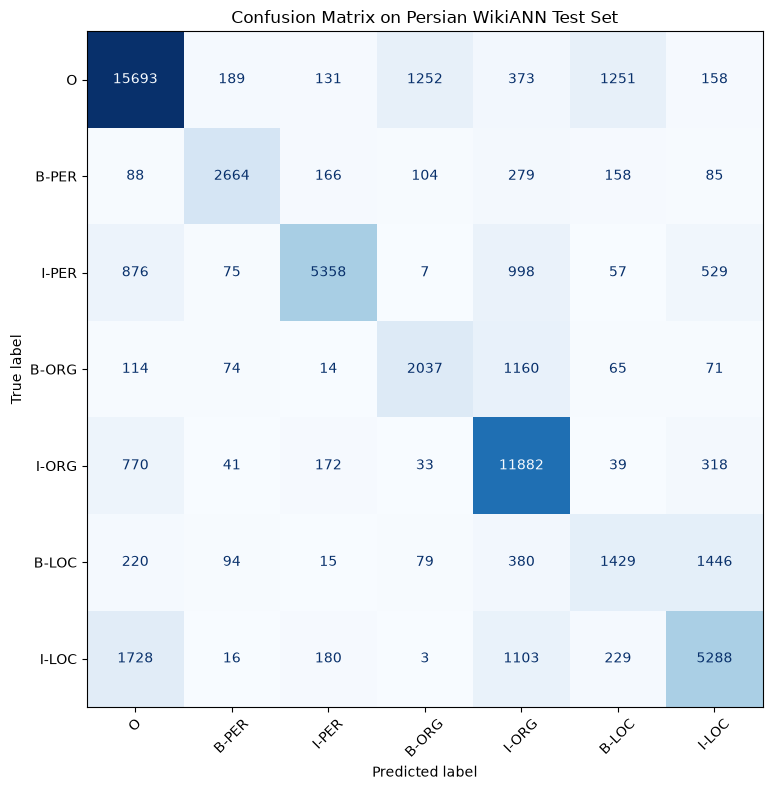

In [ ]:
# ------------------------------------------------------------
# Generate the Confusion Matrix
# ------------------------------------------------------------

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Flatten all predictions and labels
y_true = []
y_pred = []

for true_seq, pred_seq in zip(true_labels, true_predictions):
    y_true.extend(true_seq)
    y_pred.extend(pred_seq)

# Compute confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=label_names,
)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_names,
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
    colorbar=False,
)

plt.title("Confusion Matrix on Persian WikiANN Test Set")
plt.tight_layout()
plt.show()

# Step 16: Save the Best Model

In this step, the trained task adapter and its corresponding classification head are saved for future use.

Saving the adapter separately from the pre-trained XLM-RoBERTa model provides a lightweight and efficient way to reuse the trained Named Entity Recognition (NER) model for inference or further experiments without storing the entire backbone model.

In [ ]:
# ------------------------------------------------------------
# Save the Best Model
# ------------------------------------------------------------

SAVE_DIRECTORY = "./saved_adapter"

# Save the trained task adapter
model.save_adapter(
    SAVE_DIRECTORY,
    TASK_NAME,
)

# Save the corresponding prediction head
model.save_head(
    SAVE_DIRECTORY,
    TASK_NAME,
)

print("=" * 60)
print("Model saved successfully.")
print(f"Adapter directory: {SAVE_DIRECTORY}")
print("=" * 60)

Model saved successfully.
Adapter directory: ./saved_adapter


# Step 17: Reload the Saved Model for Inference

In this step, the previously saved task adapter and its corresponding classification head are reloaded into a fresh XLM-RoBERTa Base model.

Reloading the adapter demonstrates that the trained model can be restored independently of the training session and used for future inference without retraining.

In [ ]:
# ------------------------------------------------------------
# Reload the Saved Model for Inference
# ------------------------------------------------------------

# Load a fresh XLM-RoBERTa Base model
inference_model = AutoAdapterModel.from_pretrained(MODEL_NAME)

# Load the saved task adapter
adapter_name = inference_model.load_adapter(
    SAVE_DIRECTORY,
    load_as=TASK_NAME,
)

# Load the corresponding prediction head
inference_model.load_head(
    SAVE_DIRECTORY,
)

# Activate the adapter
inference_model.set_active_adapters(adapter_name)

# Move the model to the selected device
inference_model.to(device)
inference_model.eval()

print("=" * 60)
print("Saved model reloaded successfully.")
print(f"Active Adapter: {adapter_name}")
print("=" * 60)

Some weights of XLMRobertaAdapterModel were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['heads.default.3.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Saved model reloaded successfully.
Active Adapter: wikiann_ner


# Step 18: Perform Inference on New Persian Sentences

In this step, the reloaded Named Entity Recognition (NER) model is applied to new Persian sentences that were not part of the WikiANN dataset.

The model predicts the entity label for each token, demonstrating its ability to perform real-world inference after being trained on English and transferred to Persian using zero-shot cross-lingual learning.

In [ ]:
# ------------------------------------------------------------
# Perform Inference on New Persian Sentences
# ------------------------------------------------------------

# Example Persian sentences
sentences = [
    "علی در دانشگاه تهران تحصیل می‌کند.",
    "شرکت مایکروسافت در آمریکا تأسیس شد.",
    "تیم ملی فوتبال ایران در جام جهانی شرکت کرد.",
]

for sentence in sentences:

    print("=" * 60)
    print(f"Sentence: {sentence}\n")

    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = inference_model(**inputs)

    predictions = torch.argmax(outputs.logits, dim=-1)[0]

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    for token, pred in zip(tokens, predictions):
        label = label_names[pred.item()]

        if token in tokenizer.all_special_tokens:
            continue

        print(f"{token:<20} {label}")

print("=" * 60)
print("Inference completed successfully.")
print("=" * 60)

Sentence: علی در دانشگاه تهران تحصیل می‌کند.

▁علی                 B-PER
▁در                  O
▁دانشگاه             B-ORG
▁تهران               I-ORG
▁تحصیل               O
▁می                  O
▁کند                 O
.                    O
Sentence: شرکت مایکروسافت در آمریکا تأسیس شد.

▁شرکت                O
▁مایکروسافت          I-ORG
▁در                  O
▁آمریکا              B-LOC
▁تأسیس               O
▁شد                  O
.                    O
Sentence: تیم ملی فوتبال ایران در جام جهانی شرکت کرد.

▁تیم                 B-ORG
▁ملی                 I-ORG
▁فوتبال              I-ORG
▁ایران               I-ORG
▁در                  O
▁جام                 I-ORG
▁جهانی               I-ORG
▁شرکت                O
▁کرد                 O
.                    O
Inference completed successfully.


# Step 19: Summarize the Overall Experimental Results

In the final step, the experimental results obtained throughout the notebook are summarized.

The performance of the task adapter is reported for both the English validation dataset and the Persian zero-shot evaluation dataset. These results demonstrate the effectiveness of multilingual transfer learning using XLM-RoBERTa and task adapters for cross-lingual Named Entity Recognition (NER).

The experiment shows that the trained model successfully transfers NER knowledge from English to Persian without requiring any additional fine-tuning on the target language, highlighting the capability of zero-shot cross-lingual inference.

In [ ]:
# ------------------------------------------------------------
# Summarize the Overall Experimental Results
# ------------------------------------------------------------

print("=" * 70)
print("FINAL EXPERIMENTAL RESULTS")
print("=" * 70)

print(f"{'Dataset':<30}{'Precision':>12}{'Recall':>12}{'F1-score':>12}{'Accuracy':>12}")
print("-" * 70)

print(
    f"{'English Validation':<30}"
    f"{results['overall_precision']:>12.4f}"
    f"{results['overall_recall']:>12.4f}"
    f"{results['overall_f1']:>12.4f}"
    f"{results['overall_accuracy']:>12.4f}"
)

print(
    f"{'Persian Zero-shot':<30}"
    f"{zero_shot_results['overall_precision']:>12.4f}"
    f"{zero_shot_results['overall_recall']:>12.4f}"
    f"{zero_shot_results['overall_f1']:>12.4f}"
    f"{zero_shot_results['overall_accuracy']:>12.4f}"
)

print("-" * 70)

print("\nConclusion:")
print("• The task adapter achieved strong performance on the English validation dataset.")
print("• The trained adapter successfully transferred NER knowledge to Persian.")
print("• Zero-shot cross-lingual inference was performed without any Persian fine-tuning.")
print("• XLM-RoBERTa demonstrated effective multilingual knowledge transfer.")

print("=" * 70)
print("Experiment completed successfully.")
print("=" * 70)

FINAL EXPERIMENTAL RESULTS
Dataset                          Precision      Recall    F1-score    Accuracy
----------------------------------------------------------------------
English Validation                  0.7611      0.7918      0.7761      0.9104
Persian Zero-shot                   0.4163      0.5199      0.4624      0.7455
----------------------------------------------------------------------

Conclusion:
• The task adapter achieved strong performance on the English validation dataset.
• The trained adapter successfully transferred NER knowledge to Persian.
• Zero-shot cross-lingual inference was performed without any Persian fine-tuning.
• XLM-RoBERTa demonstrated effective multilingual knowledge transfer.
Experiment completed successfully.
